# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

In [1]:
print('''The business objective is framed as a supervised machine learning regression task to predict used car prices.
By leveraging features such as mileage, condition, and make, the model will identify key price drivers through
exploratory data analysis (EDA) and feature engineering. The final regression model
(e.g., Linear Regression or Random Forest) will quantify feature impact, enabling data-driven pricing strategies.''')

The business objective is framed as a supervised machine learning regression task to predict used car prices.
By leveraging features such as mileage, condition, and make, the model will identify key price drivers through
exploratory data analysis (EDA) and feature engineering. The final regression model
(e.g., Linear Regression or Random Forest) will quantify feature impact, enabling data-driven pricing strategies.


In [2]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from warnings import filterwarnings
filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
from datetime import datetime

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [3]:
df = pd.read_csv('data/vehicles.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [6]:
# Get total rows count
total_count = df.shape[0]
print(f'Total count: {total_count}\n')

# find duplicate
df_duplicate_count = df.duplicated().sum()
print(f'\nTotal duplicate count: {df_duplicate_count}\n')

# Get a summary of null values count per column
null_counts = df.isnull().sum()
df_null_columns = null_counts[null_counts > 0].sort_values(ascending=False).to_frame()

df_null_columns.rename(columns={0: 'null counts'}, inplace=True)
df_null_columns['Percentage of Null values (%)'] = (df_null_columns['null counts'] / total_count) * 100
df_null_columns


Total count: 426880


Total duplicate count: 0



,null counts,Percentage of Null values (%)
size,306361,71.767476
cylinders,177678,41.622470
condition,174104,40.785232
VIN,161042,37.725356
drive,130567,30.586347
paint_color,130203,30.501078
type,92858,21.752717
manufacturer,17646,4.133714
title_status,8242,1.930753
model,5277,1.236179


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [7]:
# Based on https://www.hubresearch.ca/bridging-the-data-gap-how-to-deal-with-missing-data-in-observational-studies/#:~:text=As%20a%20rule%20of%20thumb%2C%20if%20less,be%20deleted%20without%20any%20significant%20ramifications%20(3),
# if less than 5% of the observations are missing, the missing data can simply be deleted without any significant ramification
# manufacturer, title_status, model, odometer, fuel, transimission & year columns have total null values that is around 1 - 4% of the total count (see above).
# So we drop these rows.

df_clean = df.dropna(subset=['manufacturer', 'title_status', 'model', 'odometer', 'fuel', 'transmission', 'year'], how='any')

# VIN column is not needed
df_clean.drop(columns=['VIN', 'id'], inplace=True)

# Convert 'year' to vehicle age
df_clean['vehicle_age'] = datetime.now().year - df_clean['year']
df_clean = df_clean.drop(columns=['year'])

scaler = StandardScaler()
num_features = ['odometer', 'vehicle_age']
df_clean[num_features] = scaler.fit_transform(df_clean[num_features])

df_clean.reset_index()

print(f'total records count after dropping null values: {df_clean.shape[0]}\n')

# Fill missing numerical values with median ('price', 'year' & 'odometer' columns)
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# Replace null value with 'Unknown' for cylinders, condition, drive, paint_color & type columns
df_clean = df_clean.fillna({'size': 'Unknown', 'cylinders': 'Unknown', 'condition': 'Unknown',
                            'drive': 'Unknown', 'paint_color': 'Unknown', 'type': 'Unknown'})

print(f'total records count after cleaning null values: {df_clean.shape[0]}\n')
print('We will use this dataframe after cleaning, \"df_clean\", for our analysis')
df_clean.head()

total records count after dropping null values: 389604

total records count after cleaning null values: 389604

We will use this dataframe after cleaning, "df_clean", for our analysis


,region,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,vehicle_age
27,auburn,33590,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,-0.200762,clean,other,Unknown,Unknown,pickup,white,al,-0.277165
28,auburn,22590,chevrolet,silverado 1500,good,8 cylinders,gas,-0.131249,clean,other,Unknown,Unknown,pickup,blue,al,0.185806
29,auburn,39590,chevrolet,silverado 1500 crew,good,8 cylinders,gas,-0.403266,clean,other,Unknown,Unknown,pickup,red,al,-0.971621
30,auburn,30990,toyota,tundra double cab sr,good,8 cylinders,gas,-0.288523,clean,other,Unknown,Unknown,pickup,red,al,-0.624393
31,auburn,15000,ford,f-150 xlt,excellent,6 cylinders,gas,0.165333,clean,automatic,rwd,full-size,truck,black,al,-0.161422


The column that correlates most with 'price' is: vehicle_age
Correlation value: 0.00
odometer       0.000872
vehicle_age    0.004772
Name: price, dtype: float64


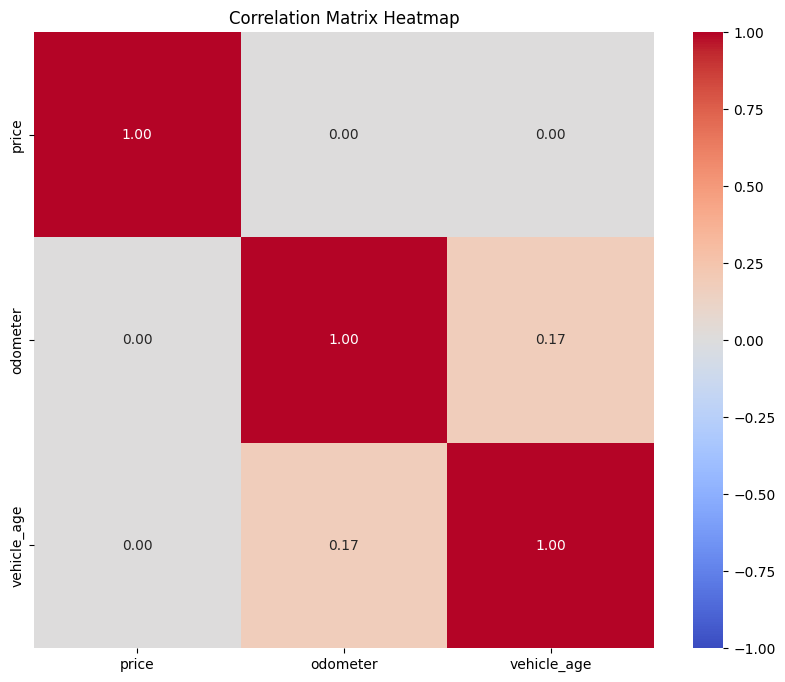

In [8]:
numeric_df = df_clean.select_dtypes(include=['number'])

# 3. Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# 4. Find which column correlates most with 'price'
# We take the absolute value to check for the strongest relationship,
# then exclude 'price' itself (which always has a correlation of 1.0)
top_correlations = correlation_matrix['price'].abs().drop('price')

highest_corr_column = top_correlations.idxmax()
highest_corr_value = correlation_matrix.loc[highest_corr_column, 'price']

print(f"The column that correlates most with 'price' is: {highest_corr_column}")
print(f"Correlation value: {highest_corr_value:.2f}")

print(top_correlations)

# 5. Display the Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.show()

Number of odometer outliers detected: 23276.

Percentage odometer outliers is (%): 5.97427131138284

         region  price   manufacturer                  model  condition  \
37       auburn   4500           jeep               cherokee  excellent   
138      auburn   4000           jeep  grand cherokee laredo       good   
204  birmingham  58977            gmc            sierra 3500    Unknown   
208  birmingham   2500      chevrolet         malibu classic    Unknown   
210  birmingham   1300  mercedes-benz                   benz    Unknown   
219  birmingham   2500            bmw                   525i       fair   
228  birmingham   5500           ford                  f-150       good   
234  birmingham  27000           ford                   f100    Unknown   
237  birmingham  20000      chevrolet                 malibu   like new   
240  birmingham  23500      chevrolet            monte carlo  excellent   
245  birmingham   5500  mercedes-benz       1929 ssk replica       good   

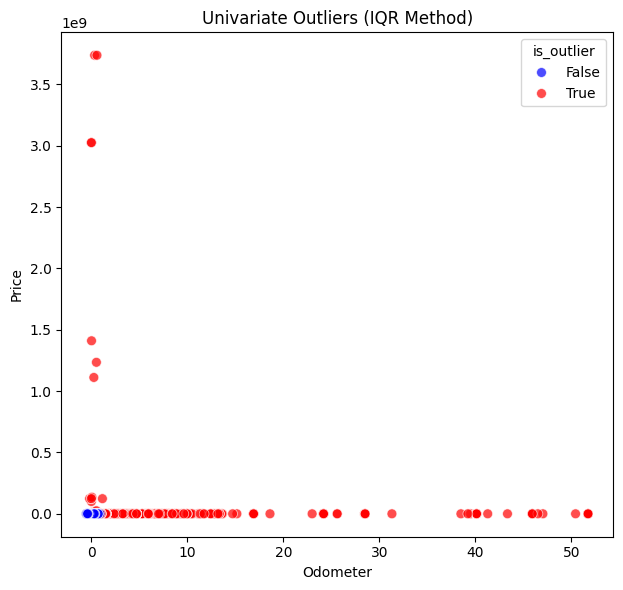

In [9]:
np.random.seed(42)

# ==========================================
# METHOD 1: IQR Method for Univariate Outliers
# ==========================================
def detect_iqr_outliers(dataframe, columns):
    outlier_indices = set()
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find indices of outliers for this column
        col_outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)].index
        outlier_indices.update(col_outliers)
    return list(outlier_indices)

# Define columns to check with IQR
numerical_cols = ['price', 'odometer', 'vehicle_age']
odometer_outlier_indices = detect_iqr_outliers(df_clean, numerical_cols)
df_clean['is_outlier'] = df_clean.index.isin(odometer_outlier_indices)

print(f'Number of odometer outliers detected: {len(odometer_outlier_indices)}.\n')
print(f'Percentage odometer outliers is (%): {len(odometer_outlier_indices) / df_clean.shape[0] * 100}\n')

print(df_clean[df_clean['is_outlier']].head(20))

# ==========================================
# METHOD 2: Isolation Forest for Multivariate Outliers
# ==========================================
# Isolate multi-dimensional anomalies (e.g., extremely high odometer for a recent year)
###iso_forest = IsolationForest(contamination=0.05, random_state=42)
###df_clean['is_anomaly'] = iso_forest.fit_predict(df_clean[['price', 'odometer', 'year']])
###df_clean['is_iso_outlier'] = df_clean['is_anomaly'] == -1

###print(f"Number of Isolation Forest outliers detected: {df['is_iso_outlier'].sum()}")

# ==========================================
# VISUALIZATION: Plotting the Outliers
# ==========================================

plt.figure(figsize=(12, 6))

# Plot 1: Price vs. Odometer (IQR Outliers)
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df_clean, x='odometer', y='price',
    hue='is_outlier', palette={True: 'red', False: 'blue'},
    alpha=0.7, s=50
)
plt.title('Univariate Outliers (IQR Method)')
plt.xlabel('Odometer')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

df_clean = df_clean.drop(odometer_outlier_indices)
df_clean.reset_index(drop=True, inplace=True)

# ==========================================
# VISUALIZATION: Plotting the Outliers
# ==========================================

# Plot 2: Price vs. Odometer (Isolation Forest Outliers)
###plt.subplot(1, 2, 2)
###sns.scatterplot(
###    data=df_clean, x='odometer', y='price',
###    hue='is_iso_outlier', palette={True: 'red', False: 'blue'},
###    alpha=0.7, s=50
###)
###plt.title('Multivariate Outliers (Isolation Forest)')
###plt.xlabel('Odometer')
###plt.ylabel('Price')


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

Degree 1: RMSE = 11043.33
Degree 2: RMSE = 10867.30
Degree 3: RMSE = 10846.40
Degree 4: RMSE = 10790.21
Degree 5: RMSE = 10750.42
Degree 6: RMSE = 10731.36
Degree 7: RMSE = 10718.26
Degree 8: RMSE = 10703.92
Degree 9: RMSE = 10696.64
Optimal Polynomial Degree: 9


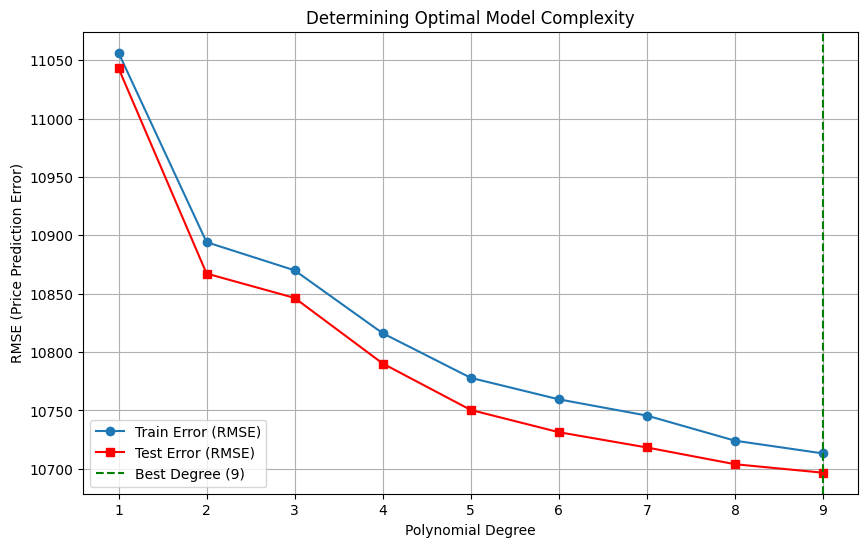

In [10]:
# 1. Split into Train and Test datasets (80/20 split)
# We only use 'vehicle_age' and 'odometer' as requested
X = df_clean[['vehicle_age', 'odometer']]
y = df_clean['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Finding the Best Degree
degrees = range(1, 10)  # Testing degrees 1 through 9
train_rmse = []
test_rmse = []

for d in degrees:
    # Transform features to polynomial degree d
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Fit model and predict
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Calculate Root Mean Squared Error (RMSE)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, model.predict(X_train_poly))))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, model.predict(X_test_poly))))

    print(f"Degree {d}: RMSE = {test_rmse[d-1]:.2f}")

# The "best" degree has the lowest Test RMSE
best_degree = degrees[np.argmin(test_rmse)]
print(f"Optimal Polynomial Degree: {best_degree}")

# 3. Visualization
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_rmse, label='Train Error (RMSE)', marker='o')
plt.plot(degrees, test_rmse, label='Test Error (RMSE)', marker='s', color='red')
plt.axvline(best_degree, color='green', linestyle='--', label=f'Best Degree ({best_degree})')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE (Price Prediction Error)')
plt.title('Determining Optimal Model Complexity')
plt.legend()
plt.grid(True)
plt.show()

Degree 1: RMSE = 122246514.34
Degree 2: RMSE = 118683426.51
Degree 3: RMSE = 118157907.82
Degree 4: RMSE = 116988961.73
Degree 5: RMSE = 116163824.02
Degree 6: RMSE = 115767198.23
Degree 7: RMSE = 115467780.98
Degree 8: RMSE = 115005883.23
Degree 9: RMSE = 114771962.16
Degree 10: RMSE = 114690901.62
Best Polynomial Degree: 10


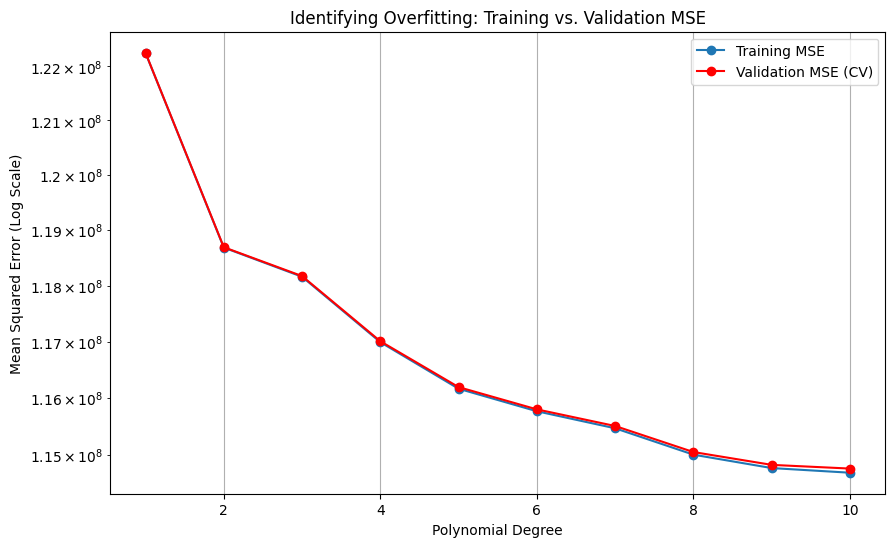

In [11]:
# 2. Track MSE across different polynomial degrees
degrees = range(1, 11)
train_mse = []
cv_mse = []

for degree in degrees:
    # Create a pipeline: Polynomial Features -> Linear Regression
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

    # Calculate Training MSE
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    train_mse.append(mean_squared_error(y_train, y_train_pred))

    # Calculate Cross-Validation MSE (5-fold)
    # neg_mean_squared_error is used; we negate it to get positive MSE
    scores = cross_val_score(model, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
    cv_mse.append(-scores.mean())

    print(f"Degree {degree}: RMSE = {train_mse[degree - 1]:.2f}")

# 3. Find the best degree
best_degree = degrees[np.argmin(cv_mse)]
print(f"Best Polynomial Degree: {best_degree}")

# 4. Visualize Underfitting vs Overfitting
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mse, label='Training MSE', marker='o')
plt.plot(degrees, cv_mse, label='Validation MSE (CV)', marker='o', color='red')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.yscale('log')  # Used to better visualize large differences in MSE
plt.title('Identifying Overfitting: Training vs. Validation MSE')
plt.legend()
plt.grid(True)
plt.show()


Ridge MSE for alpha 0.001 on Test Set: 114399254.81185381
Ridge MSE for alpha 0.1 on Test Set: 114701610.57572064
Ridge MSE for alpha 1.0 on Test Set: 115041537.62633577
Ridge MSE for alpha 10.0 on Test Set: 115768461.57277526
Ridge MSE for alpha 100.0 on Test Set: 116826857.6501082
Best Ridge Alpha: 0.001


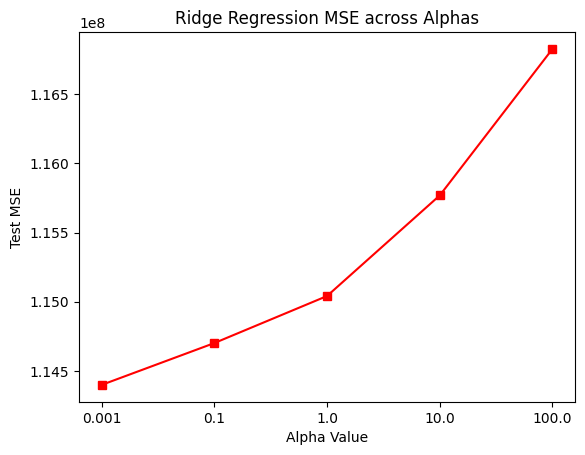

In [12]:
# Build and train the Ridge model using the best degree found previously
alphas = [0.001, 0.1, 1.0, 10.0, 100.0]
ridge_mse = []

for alpha in alphas:
    ridge_model = make_pipeline(PolynomialFeatures(best_degree), Ridge(alpha=alpha))
    ridge_model.fit(X_train, y_train)
    # Evaluate on the test set
    test_preds = ridge_model.predict(X_test)
    local_mse = mean_squared_error(y_test, test_preds)
    ridge_mse.append(local_mse)
    print(f"Ridge MSE for alpha {alpha} on Test Set: {local_mse}")

best_alpha = alphas[np.argmin(ridge_mse)]
print(f"Best Ridge Alpha: {best_alpha}")

# Graphing MSE across Ridge Alphas
plt.plot([str(a) for a in alphas], ridge_mse, marker='s', color='red')
plt.xlabel('Alpha Value')
plt.ylabel('Test MSE')
plt.title('Ridge Regression MSE across Alphas')
plt.show()


Ridge MSE score for alpha 0.001 on Test Set: [-1.16106094e+08 -1.13109832e+08 -1.15862689e+08 -1.11583996e+08
 -1.16696827e+08]
Ridge MSE score for alpha 0.1 on Test Set: [-1.16521097e+08 -1.13547338e+08 -1.16160844e+08 -1.11751627e+08
 -1.17128659e+08]
Ridge MSE score for alpha 1.0 on Test Set: [-1.17133914e+08 -1.14011402e+08 -1.16775494e+08 -1.12201865e+08
 -1.17772786e+08]
Ridge MSE score for alpha 10.0 on Test Set: [-1.18198720e+08 -1.15012883e+08 -1.17697825e+08 -1.13182435e+08
 -1.18713497e+08]
Ridge MSE score for alpha 100.0 on Test Set: [-1.19021903e+08 -1.16086454e+08 -1.18774271e+08 -1.14247188e+08
 -1.19612193e+08]


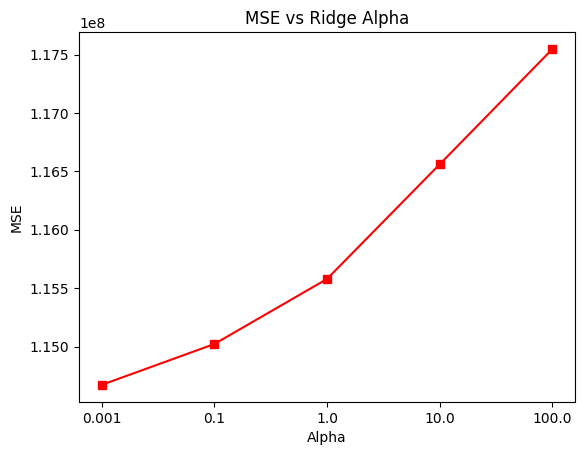

Best Degree: 10
Best Alpha: 0.001


In [13]:
ridge_mse_scores = []

for a in alphas:
    ridge_pipe = make_pipeline(PolynomialFeatures(best_degree), Ridge(alpha=a))
    scores = cross_val_score(ridge_pipe, X_test, y_test, scoring='neg_mean_squared_error', cv=5)
    ridge_mse_scores.append(-scores.mean())
    print(f"Ridge MSE score for alpha {a} on Test Set: {scores}")

best_alpha = alphas[np.argmin(ridge_mse_scores)]

# Plotting MSE for Ridge Alphas
plt.plot([str(a) for a in alphas], ridge_mse_scores, marker='s', color='red')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('MSE vs Ridge Alpha')
plt.show()

print(f"Best Degree: {best_degree}")
print(f"Best Alpha: {best_alpha}")

Final Model MSE on Test Data: 115022372.65259054


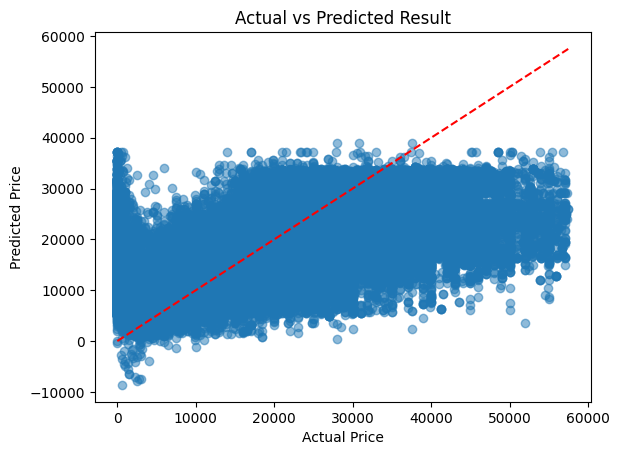

In [14]:
# Encoding 'condition' column
encoder = OrdinalEncoder()
df_clean['condition_encoded'] = encoder.fit_transform(df_clean[['condition']])
df_clean.head(100)

# Updating feature set to include encoded 'condition'
X_final = df_clean[['vehicle_age', 'odometer', 'condition_encoded']]
X_tr, X_te, y_tr, y_te = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Build and train final Ridge model
final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])
final_model.fit(X_tr, y_tr)
y_pred = final_model.predict(X_te)

final_mse = mean_squared_error(y_te, y_pred)

print(f"Final Model MSE on Test Data: {final_mse}")

# Actual vs Predicted Graph
plt.scatter(y_te, y_pred, alpha=0.5)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Result')
plt.show()

Final Model MSE on Test Data: 114613213.25685333


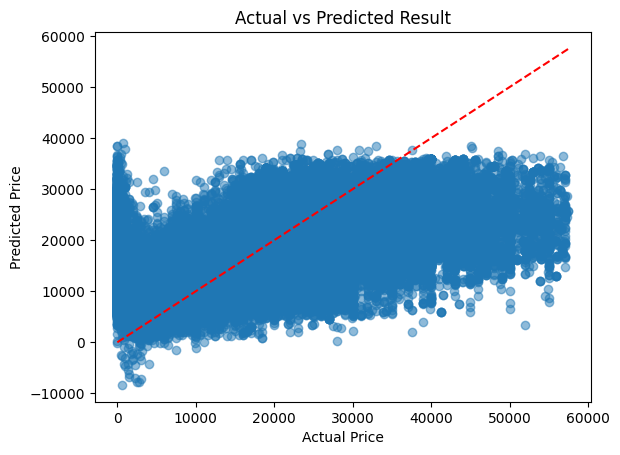

In [15]:
# Encoding 'manufacturer' column
encoder = OrdinalEncoder()
df_clean['manufacturer_encoded'] = encoder.fit_transform(df_clean[['manufacturer']])

# Updating feature set to include encoded 'manufacturer'
X_final = df_clean[['vehicle_age', 'odometer', 'condition_encoded', 'manufacturer_encoded']]
X_tr, X_te, y_tr, y_te = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Build and train final Ridge model
final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])
final_model.fit(X_tr, y_tr)
y_pred = final_model.predict(X_te)

final_mse = mean_squared_error(y_te, y_pred)

print(f"Final Model MSE on Test Data: {final_mse}")

# Actual vs Predicted Graph
plt.scatter(y_te, y_pred, alpha=0.5)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Result')
plt.show()

Final Model MSE on Test Data: 114182805.91642004


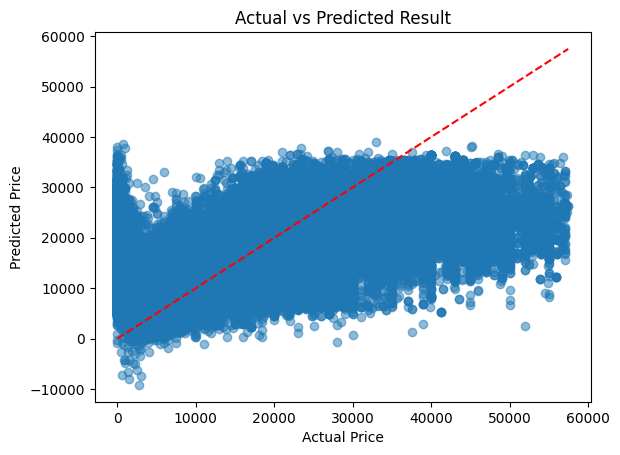

In [16]:
# Encoding 'type' column
encoder = OrdinalEncoder()
df_clean['type_encoded'] = encoder.fit_transform(df_clean[['type']])

# Updating feature set to include encoded 'type'
X_final = df_clean[['vehicle_age', 'odometer', 'manufacturer_encoded', 'condition_encoded', 'type_encoded']]
X_tr, X_te, y_tr, y_te = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Build and train final Ridge model
final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])
final_model.fit(X_tr, y_tr)
y_pred = final_model.predict(X_te)

final_mse = mean_squared_error(y_te, y_pred)

print(f"Final Model MSE on Test Data: {final_mse}")

# Actual vs Predicted Graph
plt.scatter(y_te, y_pred, alpha=0.5)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Result')
plt.show()

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

Ridge MSE score for alpha 0.001 on Test Set: [-1.15178949e+08 -1.12816392e+08 -1.15402895e+08 -1.11064386e+08
 -1.16478225e+08]
Ridge MSE score for alpha 0.1 on Test Set: [-1.15178902e+08 -1.12816337e+08 -1.15402906e+08 -1.11064423e+08
 -1.16478262e+08]
Ridge MSE score for alpha 1.0 on Test Set: [-1.15178473e+08 -1.12815846e+08 -1.15403008e+08 -1.11064767e+08
 -1.16478605e+08]
Ridge MSE score for alpha 10.0 on Test Set: [-1.15174729e+08 -1.12811443e+08 -1.15404380e+08 -1.11068521e+08
 -1.16482278e+08]
Ridge MSE score for alpha 100.0 on Test Set: [-1.15172537e+08 -1.12799863e+08 -1.15439949e+08 -1.11124728e+08
 -1.16532619e+08]


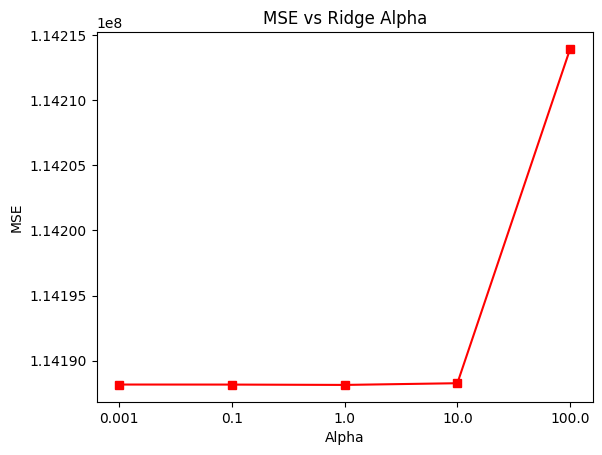

Best Alpha: 1.0


In [19]:
alphas = [0.001, 0.1, 1.0, 10.0, 100.0]
ridge_mse_scores = []

for a in alphas:
    ridge_pipe = make_pipeline(PolynomialFeatures(2), Ridge(alpha=a))
    scores = cross_val_score(ridge_pipe, X_te, y_te, scoring='neg_mean_squared_error', cv=5)
    ridge_mse_scores.append(-scores.mean())
    print(f"Ridge MSE score for alpha {a} on Test Set: {scores}")

best_alpha = alphas[np.argmin(ridge_mse_scores)]

# Plotting MSE for Ridge Alphas
plt.plot([str(a) for a in alphas], ridge_mse_scores, marker='s', color='red')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('MSE vs Ridge Alpha')
plt.show()

print(f"Best Alpha: {best_alpha}")

Final Model MSE on Test Data: 114182811.58668059


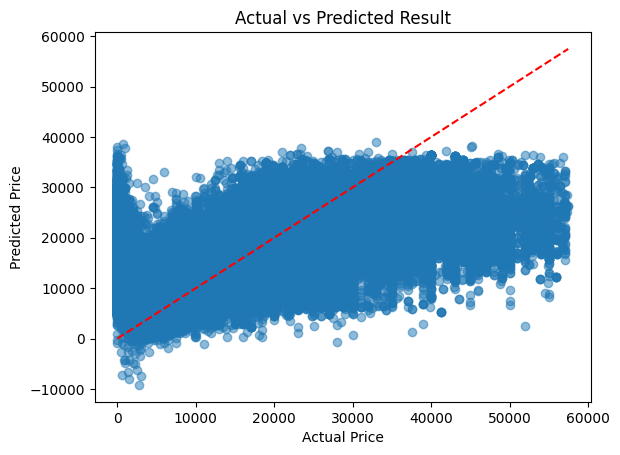

In [18]:
# Build and train final Ridge model
final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])
final_model.fit(X_tr, y_tr)
y_pred = final_model.predict(X_te)

final_mse = mean_squared_error(y_te, y_pred)

print(f"Final Model MSE on Test Data: {final_mse}")

# Actual vs Predicted Graph
plt.scatter(y_te, y_pred, alpha=0.5)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Result')
plt.show()

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.